In [1]:
import torch
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import pandas as pd

from kan import create_dataset, KAN, KANLayer
from kan.MLP import MLP

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import shap


from source import plot_f_3d, plot_f_3d, scatter_prediction_kan, kan_summary_after_fit
from source import lmdKANLayer, lmdKAN, importance_analyse_lmdKAN


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


c:\Users\Gavriil\VS_projects\lambda_KAN\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


-----
-----
## Boston housing dataset

##### Boston housing dataset

In [2]:

from sklearn.preprocessing import StandardScaler
# load dataset
boston_dataset = pd.read_csv(
    "https://edunet.kea.su/repo/EduNet-web_dependencies/datasets/boston_dataset.csv",
    index_col=0,
)
x_data = boston_dataset.iloc[:, :-1]
y_data = boston_dataset["target"].values

n_var = x_data.shape[1]

ss_x, ss_y = StandardScaler(), StandardScaler()

x_data_scaled = ss_x.fit_transform(x_data)
y_data_scaled = ss_y.fit_transform(y_data.reshape(-1, 1))

dataset = {
    'train_input': torch.Tensor(x_data_scaled),
    'test_input': torch.Tensor(x_data_scaled),
    'train_label': torch.Tensor(y_data_scaled),
    'test_label': torch.Tensor(y_data_scaled),
}

-----
### MLP

№ model trainable params: 381


| train_loss: 1.35e-01 | test_loss: 1.78e-01 | reg: 1.72e+02 | : 100%|█| 100/100 [00:04<00:00, 22.07


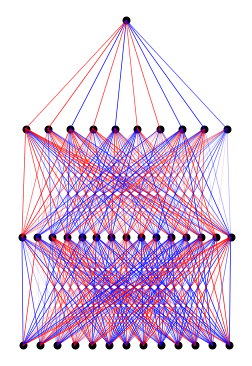

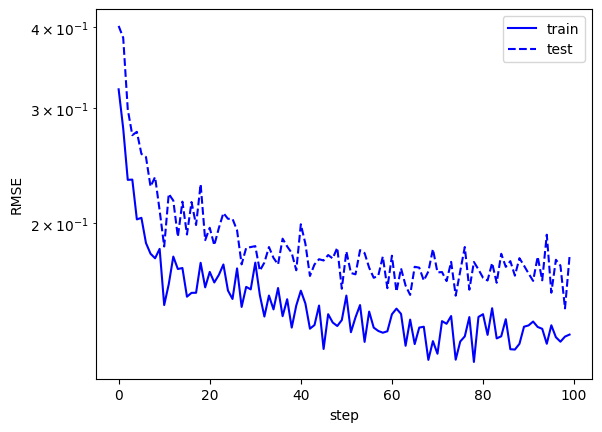

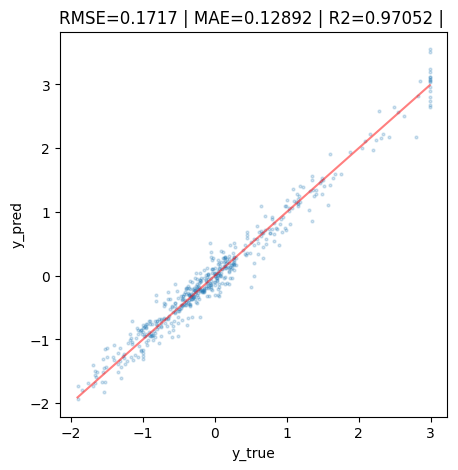

In [9]:
# initialize MLP
model = MLP(width=[n_var,15,10,1], seed=1, device=device)
pytorch_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad) # trainable params

print(f'№ model trainable params: {pytorch_total_params}')

results = model.fit(dataset, steps=100, lamb = 0, batch=250)
kan_summary_after_fit(model, dataset, results)

-----
### KAN

checkpoint directory created: ./model
saving model version 0.0
№ model trainable params: 840


description:   0%|                                                          | 0/100 [00:00<?, ?it/s]

| train_loss: 1.26e-01 | test_loss: 1.45e-01 | reg: 2.67e+01 | : 100%|█| 100/100 [00:40<00:00,  2.45


saving model version 0.1


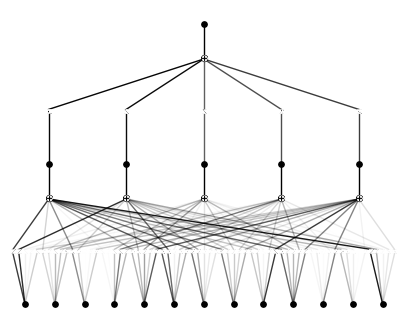

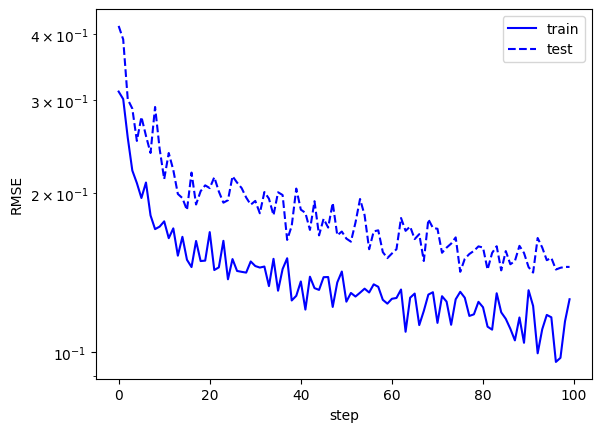

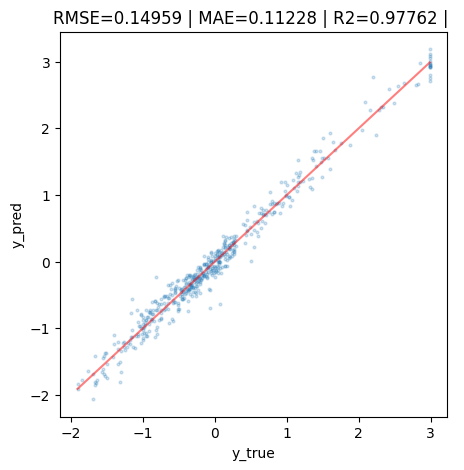

In [10]:
# initialize KAN with G=3
model = KAN(width=[n_var,5,1], grid=3, k=3, seed=1, device=device)
pytorch_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad) # trainable params

print(f'№ model trainable params: {pytorch_total_params}')

results = model.fit(dataset, steps=100, lamb=1e-4, update_grid=False, batch=250)
kan_summary_after_fit(model, dataset, results)

-----
### $\lambda$-KAN

checkpoint directory created: ./model
saving model version 0.0
№ model trainable params: 373


| train_loss: 2.89e-01 | test_loss: 3.36e-01 | reg: 2.21e+01 | : 100%|█| 150/150 [00:57<00:00,  2.60


saving model version 0.1


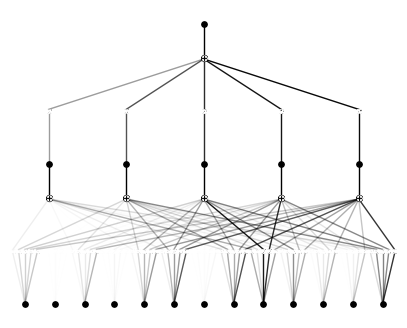

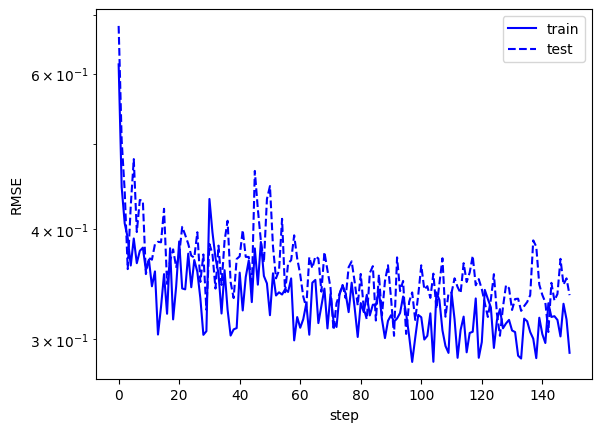

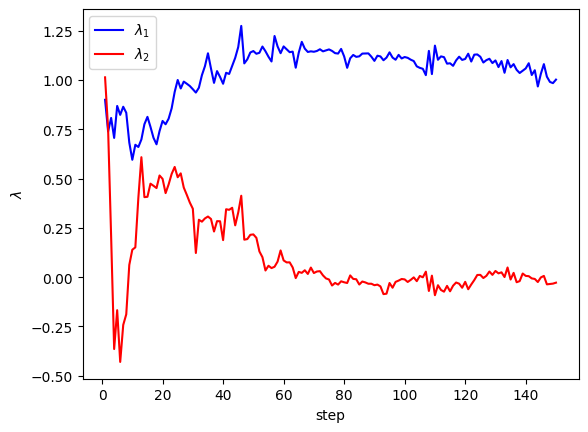

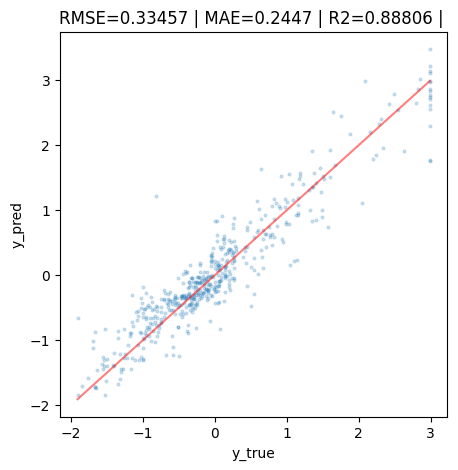

model.act_fun[0].lmd=Parameter containing:
tensor([ 1.0017, -0.0280,  0.6756, -0.0792,  1.1125, -1.7905,  0.0564,  2.6105,
        -1.7923,  1.0461,  0.4720, -0.2349,  3.4467], requires_grad=True)


In [4]:
# initialize lmdKAN with G=3
model = lmdKAN(width=[n_var,5,1], grid=3, k=3, seed=1, device=device)
pytorch_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad) # trainable params

print(f'№ model trainable params: {pytorch_total_params}')

results = model.fit(dataset, steps=150, lamb = 1e-4, 
                    lamb_lmd_interm=0.0, lamb_lmd_final=0.0, reg_type='entropy',
                    batch=250)
kan_summary_after_fit(model, dataset, results, lmdKAN=True)
print(f'{model.act_fun[0].lmd=}')

PermutationExplainer explainer: 507it [05:25,  1.52it/s]                         


module of Input importance:


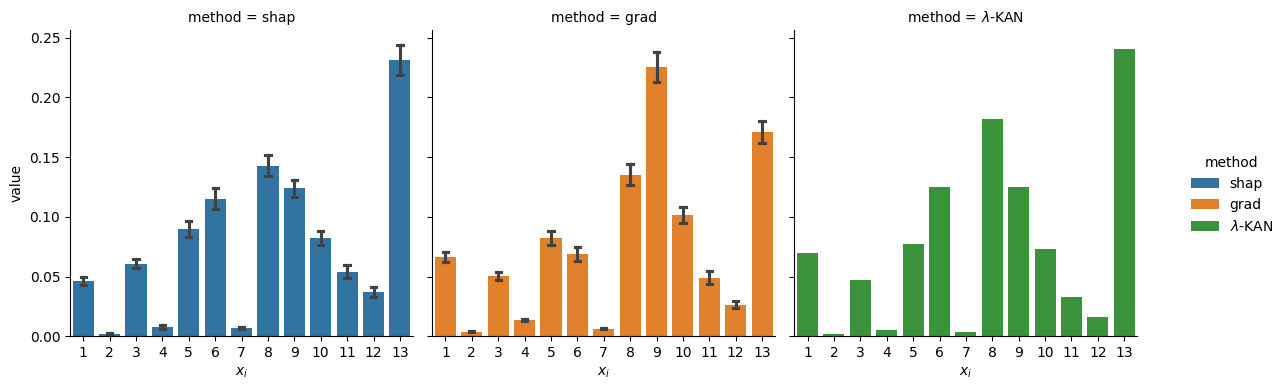

Input importance:


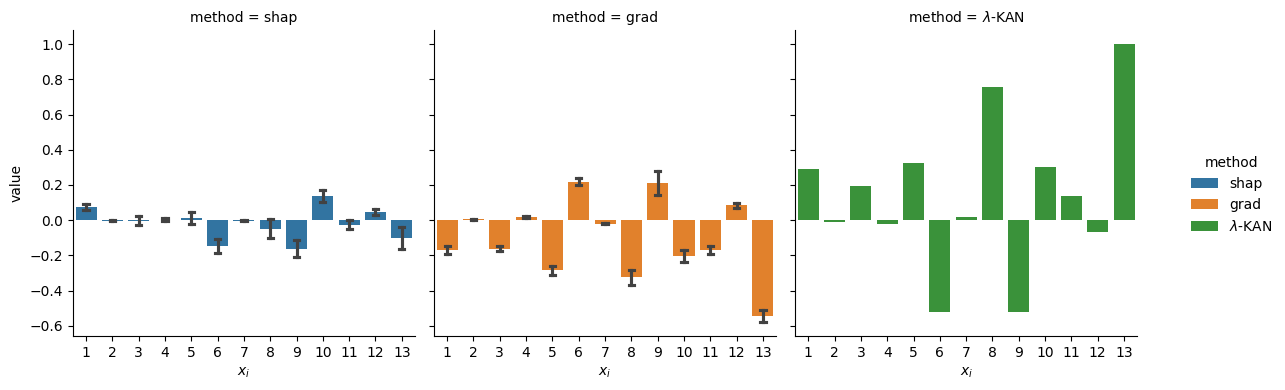

In [5]:
importance_analyse_lmdKAN(model, dataset)

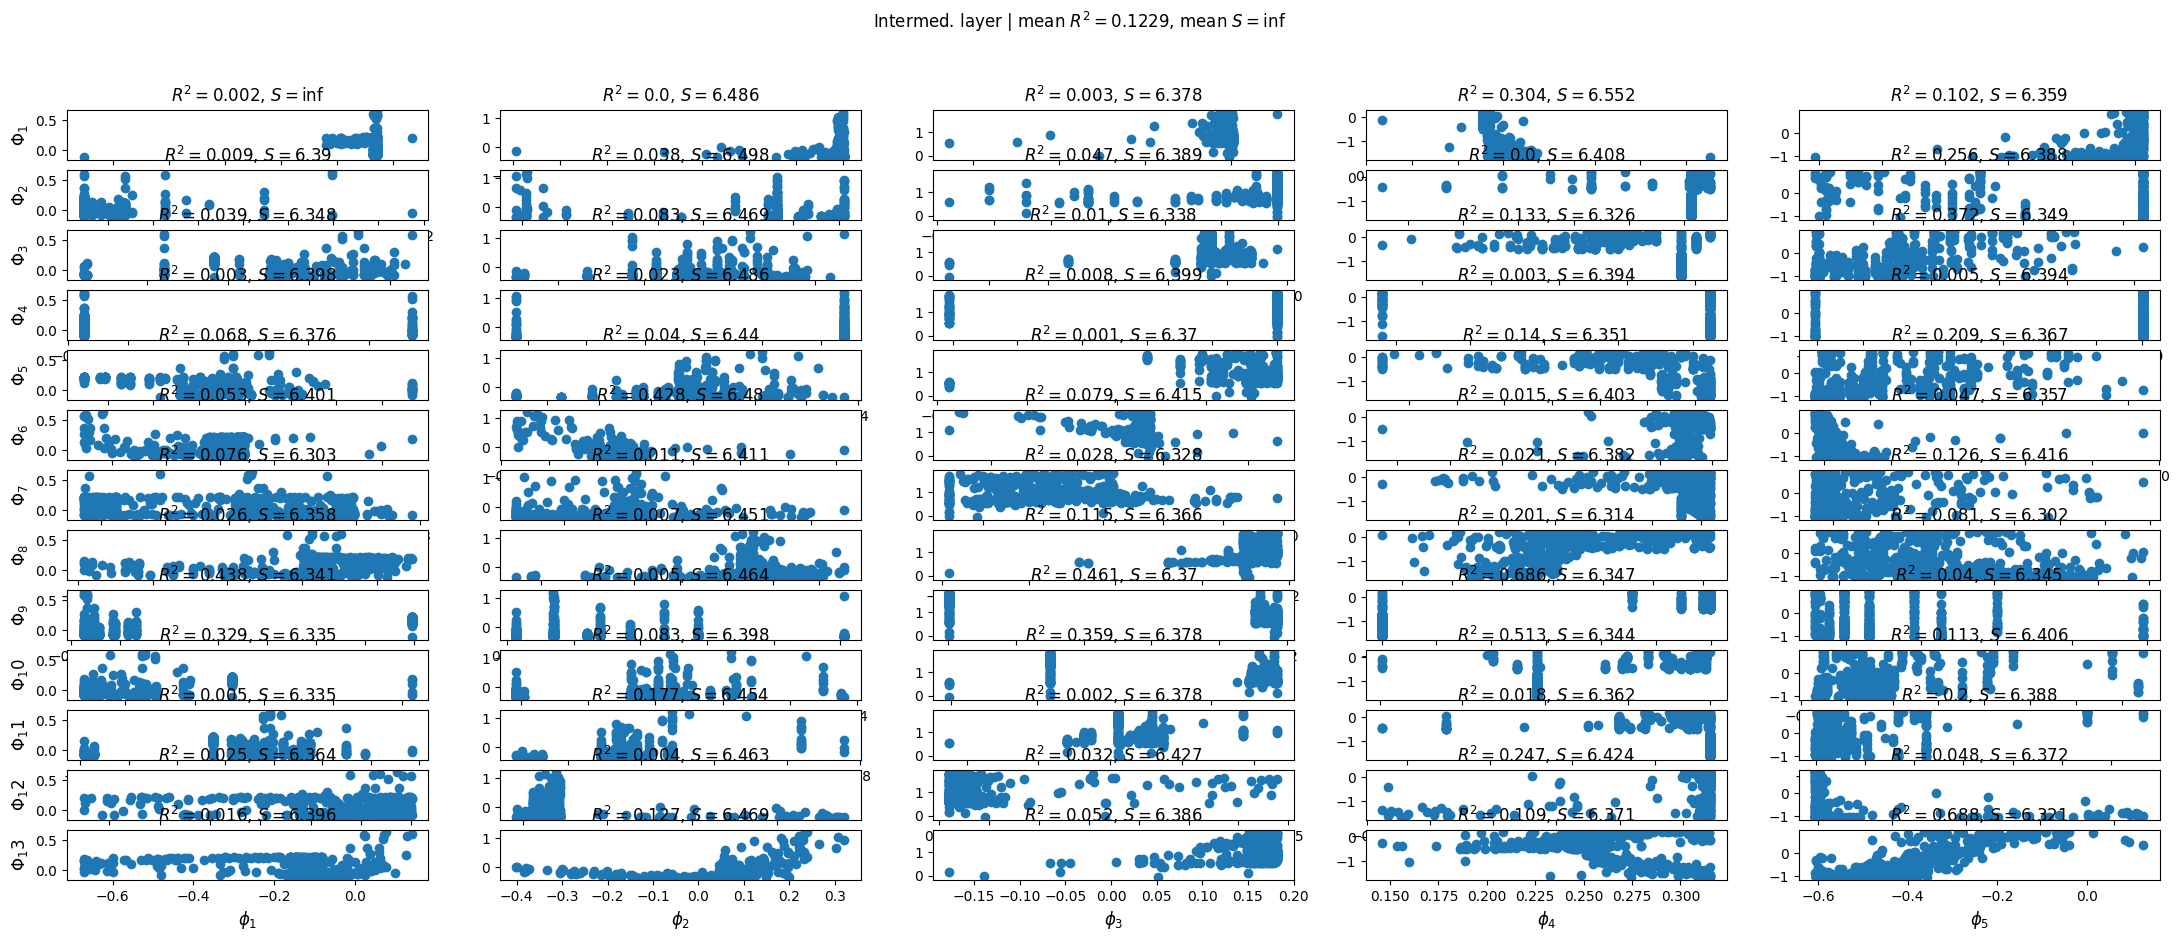

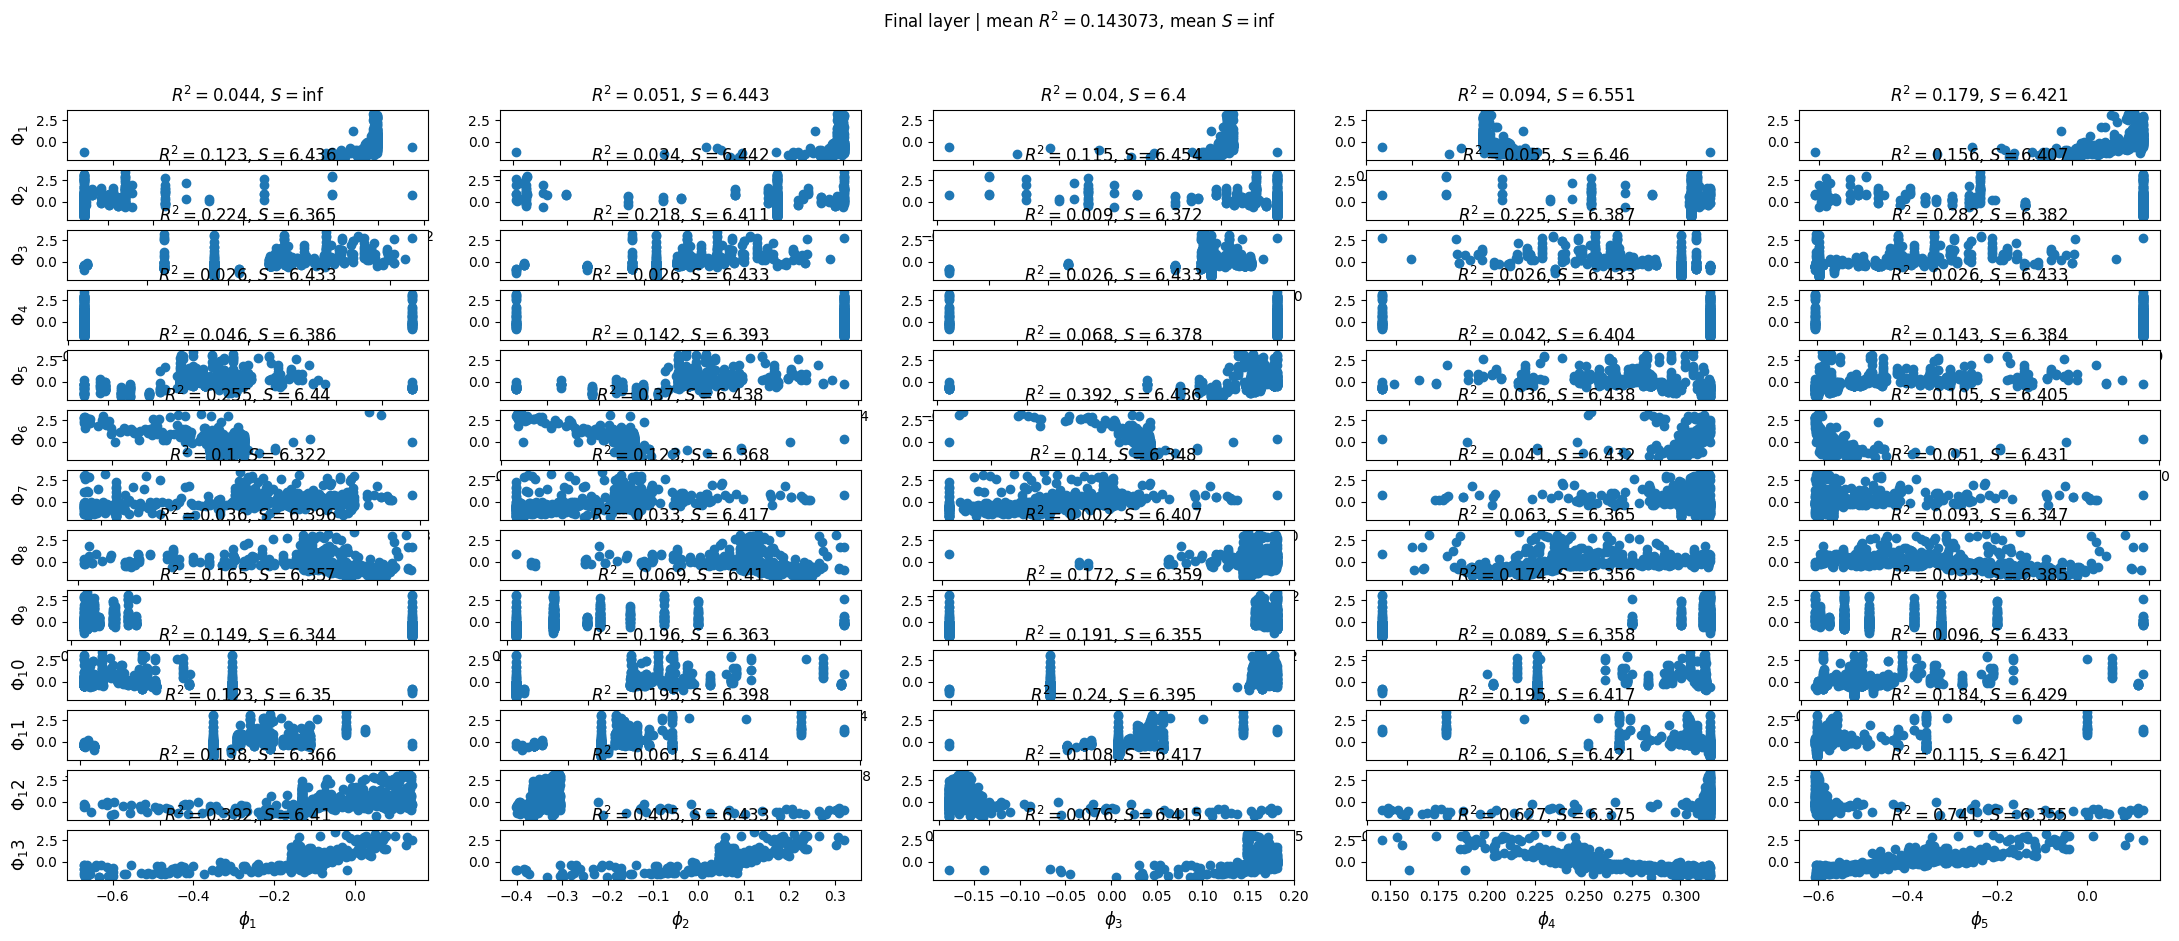

{'mean_r2': 0.14307301735792022, 'mean_matrix_entropy': inf}

In [6]:
model.lmd_corr_plot(title_text='Intermed. layer')
model.lmd_corr_plot(fin_layer=True, title_text='Final layer')